# Preparation of Survey items to validate GBN classification
Felix Zaussinger | 21.07.2022

**Core Analysis Goal(s)**
1. Code for stratified random draw of green, brown and neutral occupations from our consolidated short lists
2. Export to text files along the lines of Malte's approach
3. Implement in Qualtrics

**Key Insight(s)**
1.
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils

# import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

#### Input data

In [2]:
df_sl = pd.read_csv(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "esco_level_gbn_classification_short_lists.csv",
    ),
    index_col=0,
)

df_sl_tobi = pd.read_csv(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "esco_level_gbn_classification_short_lists_tobi.csv",
    ),
    index_col=0,
)

In [46]:
df_sl.groupby("gbn_classification_short_list").count()

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess
gbn_classification_short_list,,,,,
brown,207,207,207,207,207
green,91,91,91,91,91
neutral,2710,2710,2710,2710,2709


#### Comparison between ESCO-based and manual classification
- [quantification via confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix)
- very little overlap
- not very surprising though as the reference classification is based on assigning the class with the highest skill share, so neutral occupations will dominate


In [3]:
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix

labels = ["green", "brown", "neutral"]
cm = confusion_matrix(
    y_true=df_sl.gbn_classification_short_list,
    y_pred=df_sl.gbn_classification_esco,
    labels=labels,
    # normalize="true"
)

cm_sl = pd.DataFrame(cm, columns=labels, index=labels)
cm_sl

,green,brown,neutral
green,25,0,66
brown,0,2,205
neutral,4,0,2706


In [4]:
labels = ["green", "brown", "neutral"]
cm = confusion_matrix(
    y_true=df_sl_tobi.gbn_classification_short_list,
    y_pred=df_sl_tobi.gbn_classification_esco,
    labels=labels,
    # normalize="true"
)

cm_sl_tobi = pd.DataFrame(cm, columns=labels, index=labels)
cm_sl_tobi

,green,brown,neutral
green,25,0,66
brown,0,0,63
neutral,4,2,2848


In [5]:
df_sl.groupby("gbn_classification_short_list").count()

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess
gbn_classification_short_list,,,,,
brown,207,207,207,207,207
green,91,91,91,91,91
neutral,2710,2710,2710,2710,2709


#### Stratified random draw

- use `.groupby` combined with `.sample` to draw N samples for each category
- use `.sample(frac=1)` to shuffle the sample
- [link](https://stackoverflow.com/questions/44114463/stratified-sampling-in-pandas)

In [6]:
# select list version
df = df_sl

# sample size per category
n_sample = 10
n_categories = 3

# random draw of size n_sample out of each category (n_sample * 3 categories)
strat_sample = df.groupby("gbn_classification_short_list", group_keys=False).apply(
    lambda x: x.sample(min(len(x), n_sample))
)

# shuffle the sample
strat_sample_shuffled = strat_sample.sample(frac=1)

strat_sample_shuffled

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess,gbn_classification_short_list
Column1,,,,,,
1111,http://data.europa.eu/esco/occupation/2480f8b0...,refuse vehicle driver,Refuse vehicle drivers drive the large vehicle...,neutral,neutral,green
946,http://data.europa.eu/esco/occupation/daa6197d...,wax bleacher,Wax bleachers operate and maintain filter pres...,neutral,brown,brown
2162,http://data.europa.eu/esco/occupation/72d4b5a3...,"import export specialist in sugar, chocolate a...","Import export specialists in sugar, chocolate ...",neutral,neutral,neutral
2195,http://data.europa.eu/esco/occupation/6c7d333a...,forestry inspector,Forestry inspectors monitor forestry operation...,neutral,neutral,green
539,http://data.europa.eu/esco/occupation/d1b1dfdf...,costume designer,Costume designers develop a costume design con...,neutral,neutral,neutral
939,http://data.europa.eu/esco/occupation/8f71761e...,coking furnace operator,Coking furnace operators monitor the operation...,neutral,brown,brown
1711,http://data.europa.eu/esco/occupation/febd4100...,air pollution analyst,Air pollution analysts conduct field and lab t...,neutral,green,green
2214,http://data.europa.eu/esco/occupation/061f56c6...,performance video operator,Performance video operators control the (proje...,neutral,neutral,neutral
2339,http://data.europa.eu/esco/occupation/bced9b86...,manicurist,Manicurists provide fingernail care. They clea...,neutral,neutral,neutral


#### test_set_v1
- 30 occupations per participant
- no condition that each occupation needs to be seen by two participants

In [7]:
# directory and files
target_dir = (
    r"T:\Documents\Projects\04_jrc_green-skills-regional\02_research\user study"
)
target_folder = "test_set_v1"
target_file = "test_set_shuffled_{}.txt"

# select list version
df = df_sl

# sample size per category
n_sample = 10
n_categories = 3
n_surveys = 20
newline = "\n"

# create N surveys
all_samples = []
for survey_id in range(1, n_surveys + 1):

    # random draw of size n_sample out of each category (n_sample * 3 categories), then shuffle the sample
    strat_sample = df.groupby("gbn_classification_short_list", group_keys=False).apply(
        lambda x: x.sample(min(len(x), n_sample))
    )
    strat_sample_shuffled = strat_sample.sample(frac=1)
    all_samples.append(strat_sample_shuffled)

    # create new survey file
    f = open(
        os.path.join(target_dir, target_folder, target_file.format(survey_id)),
        "w+",
        encoding="utf-8",
    )

    # iterate over occupations in drawn sample
    item_count = 1
    for i, row in strat_sample_shuffled.iterrows():
        occ_label = row["preferredLabel"]
        occ_desc = row["description"]

        # build question/answer structure
        f.write("{}. {}\n".format(item_count, occ_desc))
        f.write(newline)
        f.write("Green\nBrown\nNeutral\nUnsure\n")
        f.write(newline)

        # make sure no block is added after the last question
        if item_count < n_sample * n_categories:
            f.write("[[Block]]")
            f.write(newline)

        # update count
        item_count += 1

    f.close()

gbn_classification_short_list
brown      137
green       85
neutral    195
Name: conceptUri, dtype: int64
                               duplicate
gbn_classification_short_list           
brown                                 63
green                                115
neutral                                5


<AxesSubplot:>

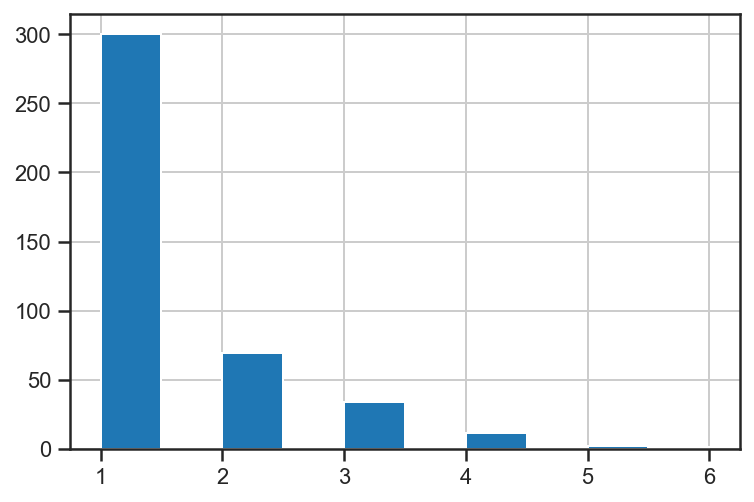

In [8]:
df_all_samples = pd.concat(all_samples)

# unique occupations per category
df_all_samples.groupby("gbn_classification_short_list").count()
print(
    df_all_samples.drop_duplicates()
    .groupby("gbn_classification_short_list")
    .count()
    .iloc[:, 0]
)

# duplicates per category
df_all_samples["duplicate"] = df_all_samples.duplicated()
print(df_all_samples.groupby("gbn_classification_short_list").sum())

# all occupations in the sample at least twice?
df_all_samples.groupby("preferredLabel").count().iloc[:, 0].hist()

#### test_set_v2
- 30 occupations per participant
- condition that each occupation needs to be seen by two participants
- surveys with uneven IDs are unique draws, surveys with the following even ID
contain the same sample, but a shuffled set

In [9]:
info_button_text = """<br>
<br>
<button id="button">Display definitions</button>
<div id="infodiv" style="display:none;">
<small>
<b>Definitions:</b>
<ul>
<li><b>Green occupations:</b> contribute to <em>decreasing the negative impact of human activity on the environment</em> (e.g., through reducing GHG emissions, air- &amp; water-pollution, restoring ecosystems or enhancing biodiversity) or to enabling the green transition (e.g., through expanding the electricity transmission &amp; distribution network), and are <em>predominantly found in key green economy sectors</em> (e.g., Renewable Energy Generation, Energy Efficiency, Environment Protection, Recycling and Waste Reduction, Water Supply).</li>
<li><b>Brown occupations:</b> contribute to <em>maintaining or increasing the negative impact of human activity on the environment</em> (e.g., through emitting GHG's, causing air- &amp; water-pollution, damaging ecosystems or reducing biodiversity) and are <em>predominantly found in sectors with above-average emission &amp; pollution intensities</em> (e.g., Mining, Oil and Gas Extraction, Manufacturing).</li>
<li><b>Neutral occupations:</b> <em>neither </em>contribute to significantly <em>decreasing nor increasing the negative impact of human activity on the environment</em> and <em>neither affect the direction nor speed of the green transition to a first order</em> (e.g., Hairdressers, Translators).</li>
</ul>
</small>
</div>"""

In [47]:
# directory and files
target_dir = (
    r"T:\Documents\Projects\04_jrc_green-skills-regional\02_research\user study"
)
target_folder = "test_set_v4"
target_file = "test_set_shuffled_{}.txt"

if not os.path.exists(os.path.join(target_dir, target_folder)):
    os.makedirs(os.path.join(target_dir, target_folder))

# select list version
df = df_sl

# sample size per category
n_sample = 10
n_categories = 3
n_surveys = 20
newline = "\n"

# create N surveys
all_samples = []
for survey_id in range(1, n_surveys + 1):

    # create unique draw for uneven survey id's
    if (survey_id % 2) != 0:
        # random draw of size n_sample out of each category (n_sample * 3 categories)
        strat_sample = df.groupby(
            "gbn_classification_short_list", group_keys=False
        ).apply(lambda x: x.sample(n=min(len(x), n_sample)))

    # shuffle the sample: for even survey id's, the sample of the previous (uneven) id is shuffled
    strat_sample_shuffled = strat_sample.sample(frac=1)
    all_samples.append(strat_sample_shuffled)

    # create new survey file
    f = open(
        os.path.join(target_dir, target_folder, target_file.format(survey_id)),
        "w+",
        encoding="utf-8",
    )

    # iterate over occupations in drawn sample
    item_count = 1
    for i, row in strat_sample_shuffled.iterrows():
        occ_label = row["preferredLabel"]
        occ_desc = row["description"].strip()

        # build question/answer structure
        f.write("{}. {}\n".format(item_count, occ_desc))
        f.write(info_button_text)
        f.write(newline)
        f.write(newline)
        f.write("Green\nBrown\nNeutral\nUnsure\n")
        f.write(newline)

        # make sure no block is added after the last question
        if item_count < n_sample * n_categories:
            f.write("[[Block]]")
            f.write(newline)

        # update count
        item_count += 1

    f.close()

#### Evaluation of sample
- note that since some categories are smaller (G < B < N), more duplicates are in the
 combined sample overall
- ~ 240 / 600 occupations are unique

gbn_classification_short_list
brown      84
green      65
neutral    99
Name: conceptUri, dtype: int64
                               duplicate
gbn_classification_short_list           
brown                                116
green                                135
neutral                              101
(array([ 2,  4,  6, 10], dtype=int64), array([208,  30,   9,   1], dtype=int64))


array([[<AxesSubplot:title={'center':'brown'}>,
        <AxesSubplot:title={'center':'green'}>],
       [<AxesSubplot:title={'center':'neutral'}>, <AxesSubplot:>]],
      dtype=object)

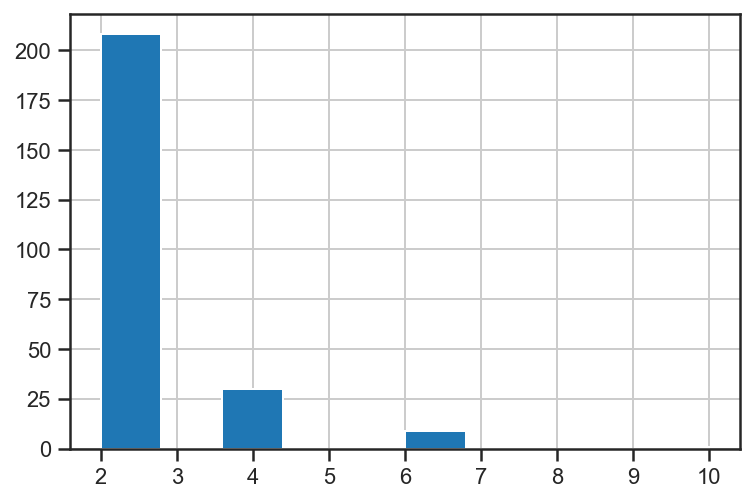

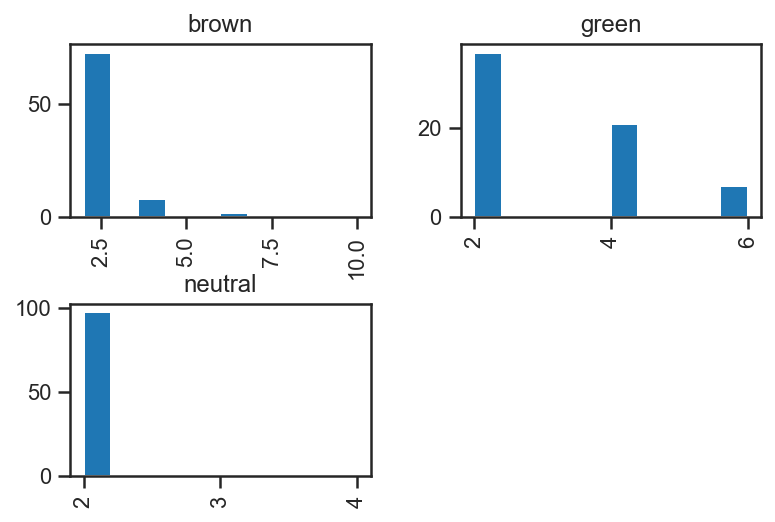

In [48]:
df_all_samples = pd.concat(all_samples)
df_all_samples.drop_duplicates(subset=["conceptUri"])

# unique occupations per category
df_all_samples.groupby("gbn_classification_short_list").count()
print(
    df_all_samples.drop_duplicates()
    .groupby("gbn_classification_short_list")
    .count()
    .iloc[:, 0]
)

# duplicates per category
df_all_samples["duplicate"] = df_all_samples.duplicated()
print(df_all_samples.groupby("gbn_classification_short_list").sum())

# all occupations in the sample at least twice?
df_all_samples.groupby("preferredLabel").count().iloc[:, 0].hist()

df_all_samples.groupby("preferredLabel").count()
print(
    np.unique(
        df_all_samples.groupby("preferredLabel").count().iloc[:, 0], return_counts=True
    )
)

df_all_samples.groupby(
    ["preferredLabel", "gbn_classification_short_list"]
).count().iloc[:, 0].reset_index().hist(
    by="gbn_classification_short_list", column="conceptUri", stacked=True
)

In [54]:
for sample in all_samples:
    n = sample.groupby("gbn_classification_short_list").count().iloc[:, 0]
    sample_balanced = (n == n_sample).all()
    print(sample_balanced)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [49]:
df_all_samples.drop_duplicates(subset=["conceptUri"]).sort_values(
    "gbn_classification_short_list"
)

,conceptUri,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess,gbn_classification_short_list,duplicate
Column1,,,,,,,
1005,http://data.europa.eu/esco/occupation/8d3fd879...,precast moulder,Precast moulders handcast decorative and struc...,brown,brown,brown,False
1070,http://data.europa.eu/esco/occupation/502fe307...,injection moulding operator,Injection moulding operators operate and monit...,neutral,neutral,brown,False
863,http://data.europa.eu/esco/occupation/ce5b1eb1...,dip tank operator,"Dip tank operators set up and tend dip tanks, ...",neutral,neutral,brown,False
719,http://data.europa.eu/esco/occupation/a8ccc522...,chemical tester,Chemical testers are responsible for the rapid...,neutral,neutral,brown,False
505,http://data.europa.eu/esco/occupation/00ab29a3...,mine surveyor,Mine surveyors prepare and maintain mining pla...,neutral,neutral,brown,False
...,...,...,...,...,...,...,...
343,http://data.europa.eu/esco/occupation/8db28ebf...,specialist pharmacist,Specialist pharmacists provide specialist serv...,neutral,neutral,neutral,False
1430,http://data.europa.eu/esco/occupation/0a94df75...,stringed musical instrument maker,Stringed musical instrument makers create and ...,neutral,neutral,neutral,False
1683,http://data.europa.eu/esco/occupation/6d1e2801...,construction safety inspector,Construction safety inspectors monitor constru...,neutral,neutral,neutral,False


#### Info text
- Green occupations: contribute to decreasing the impact of human activity on the
natural environment (e.g., through decreasing GHG emissions, air- & water-pollution
or enhancing biodiversity) or to enabling the green transition (e.g., through
expanding our electricity transmission & distribution network).
- Brown occupations: contribute to increasing the impact of human activity on the natural environment (e.g., through increasing GHG emissions, air- & water-pollution or reducing biodiversity).
- Neutral occupations: neither contribute to significantly decreasing nor increasing the impact of human activity on the natural environment and are neither affecting the direction nor speed of the green transition to a first order (e.g., hairdresser, translator).